In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
import os
os.makedirs("../artifacts", exist_ok=True)
sys.path.append("..")
from src.components.data_ingestion import DataLoader,engine


loader = DataLoader("cleaned_hotel_data",engine)
df = loader.load()




# I split the data and placed into artifacts folder for ML model.

Resort_hotel = df[df['hotel'] == 'Resort Hotel']
Resort_hotel.to_csv("../artifacts/Resort_hotel.csv", index=False)

City_hotel = df[df['hotel'] == 'City Hotel']
City_hotel.to_csv("../artifacts/City_hotel.csv", index=False)




[ 2026-04-20 19:05:45,824 ] — Line: 132 — hotel_pricing — INFO — DataLoader initialized for table: cleaned_hotel_data
[ 2026-04-20 19:05:45,826 ] — Line: 149 — hotel_pricing — INFO — Loading data from table: cleaned_hotel_data
[ 2026-04-20 19:05:46,489 ] — Line: 152 — hotel_pricing — INFO — Data loaded successfully. Shape: (55713, 22)


In [3]:
# Exploratory Data Analysis for the whole data frame

df.head(5)
df.describe()
df.isnull().sum()
df.columns
df.dtypes
df.shape
df['adr'].describe()
df['adr'].nlargest(10)




55623    451.5
5937     384.0
5976     382.0
55524    375.5
3640     369.0
18029    367.0
45935    365.0
13398    359.0
13639    359.0
13523    357.0
Name: adr, dtype: float64

In [4]:
# -----------------------------
# 1. Drop assigned_room_type
# -----------------------------
# They are duplicates; reserved_room_type is the correct one
df.drop(['assigned_room_type'], axis=1, inplace=True)


# -----------------------------
# 2. Rename reserved_room_type → room_class
# -----------------------------
df.rename(columns={'reserved_room_type': 'room_class'}, inplace=True)


# -----------------------------
# 3. Remove ADR outliers (<5 or >1000)
# -----------------------------
df = df[(df['adr'] > 5) & (df['adr'] < 1000)]


# -----------------------------
# 4. Remove Complementary segment
# -----------------------------
df = df[df['market_segment'] != 'Complementary']


# -----------------------------
# 5. Remove Undefined distribution channel
# -----------------------------
df = df[df['distribution_channel'] != 'Undefined']


# -----------------------------
# 6. Remove room type P (0 ADR)
# -----------------------------
df = df[df['room_class'] != 'P']


# -----------------------------
# 7. Map room_class codes → descriptive names
# -----------------------------
room_map = {
    'A': 'Standard King',
    'B': 'Standard Twin',
    'C': 'Premier King',
    'D': 'Premier Twin',
    'E': 'Club King',
    'F': 'Club Twin',
    'G': 'Suite King',
    'H': 'Executive Suite',
    'I': 'Deluxe King',
    'K': 'Deluxe Twin',
    'L': 'Presidential Suite'
}

df['room_class'] = df['room_class'].replace(room_map)


# -----------------------------
# 8. Merge children + babies → Kids
# -----------------------------
df['Kids'] = df['children'].astype(int) + df['babies'].astype(int)


# -----------------------------
# 9. Drop original children/babies
# -----------------------------
df.drop(['children', 'babies'], axis=1, inplace=True)

# -----------------------------
# 10. Drop original children/babies
# -----------------------------
''' I checked the yearly growth and found there's incomplete data in 2015, and 2017 so I will remove these years.'''

df = df[~df['arrival_date_year'].isin([2015, 2017])]


# -----------------------------
# 11. Export cleaned dataset
# -----------------------------
df.to_csv("cleaned_hotel_data.csv", index=False)


KeyError: "['assigned_room_type'] not found in axis"

In [ ]:
df.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,distribution_channel,room_class,booking_changes,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,Kids
3738,Resort Hotel,0,109,2016,January,1,1,0,1,2,...,TA/TO,Standard King,0,0,Transient-Party,59.94,0,1,1/2/2016,0
3739,Resort Hotel,0,109,2016,January,1,1,0,1,2,...,TA/TO,Executive Suite,0,0,Transient-Party,116.10,1,1,1/2/2016,2
3740,Resort Hotel,1,2,2016,January,1,1,0,1,2,...,TA/TO,Premier Twin,0,0,Transient,89.00,0,1,1/1/2016,0
3741,Resort Hotel,0,88,2016,January,1,1,0,2,2,...,TA/TO,Standard King,0,0,Transient,73.46,0,2,1/3/2016,0
3742,Resort Hotel,1,20,2016,January,1,1,0,2,2,...,TA/TO,Suite King,0,0,Transient,119.00,0,0,12/22/2015,2


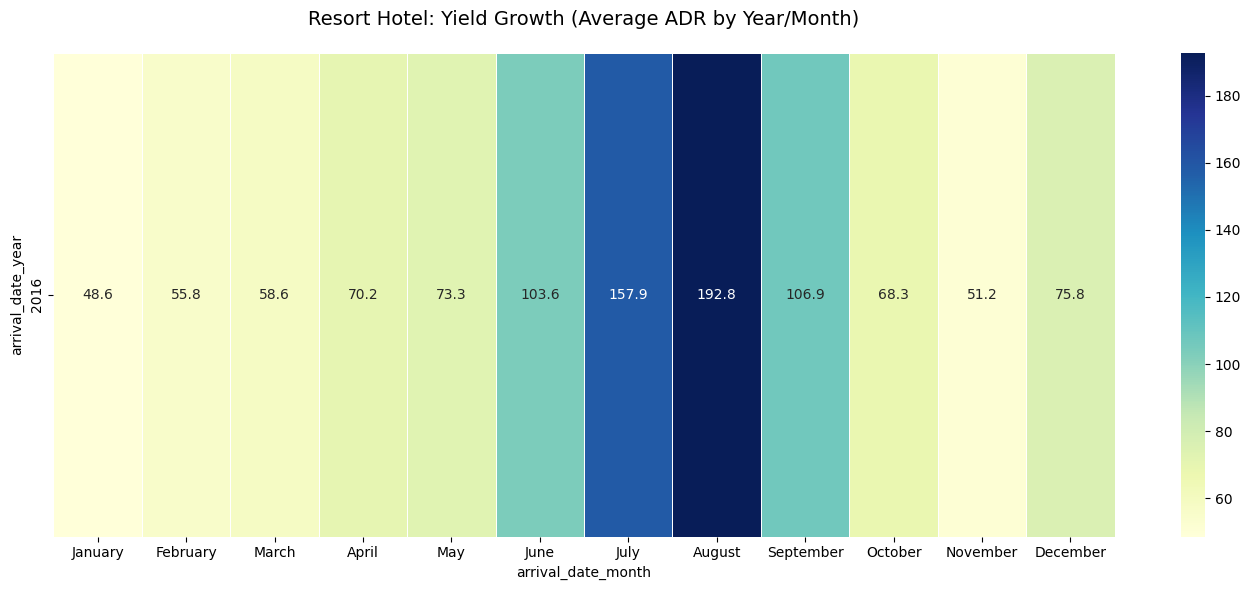

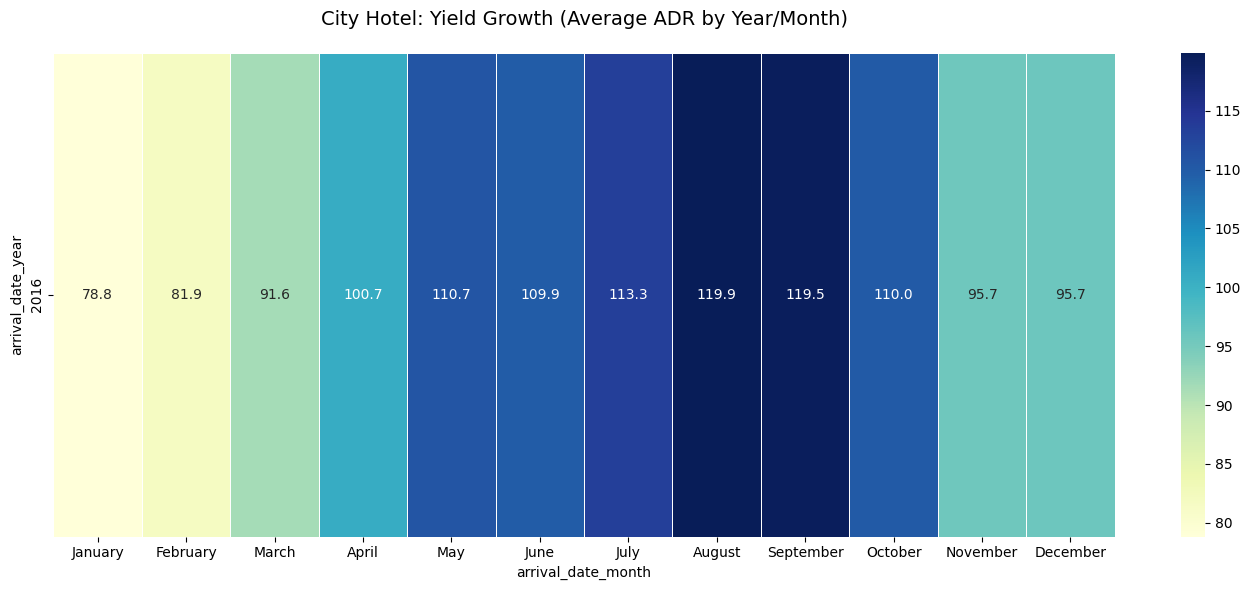

In [ ]:
''' I checked the yearly growth and found there's incomplete data in 2015, and 2017 so I will remove these years.'''

for h in df['hotel'].unique():
    
    temp = df[df['hotel'] == h]

    # Chronological order for consistent plotting
    month_order = [
        'January', 'February', 'March', 'April', 'May', 'June', 
        'July', 'August', 'September', 'October', 'November', 'December'
    ]

    data_pivot_year = temp.pivot_table(
        index='arrival_date_year', 
        columns='arrival_date_month', 
        values='adr', 
        aggfunc='mean'
    ).reindex(columns=month_order)


    plt.figure(figsize=(14, 6))
    sns.heatmap(data_pivot_year, cmap='YlGnBu', annot=True, fmt=".1f", linewidths=.5)
    plt.title(f'{h}: Yield Growth (Average ADR by Year/Month)', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

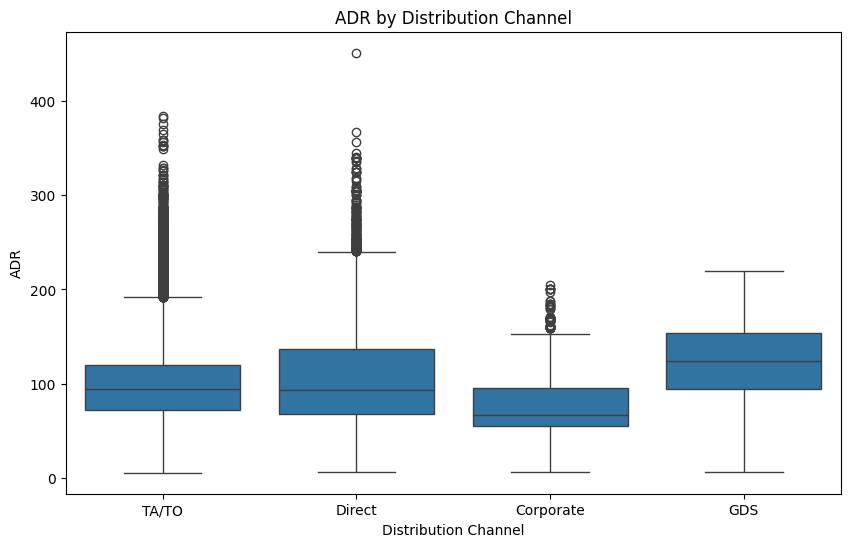

In [ ]:
# Boxplot for ADR by Distribution Channel

''' I removed Undefined from distribution_channel '''

plt.figure(figsize=(10, 6))
sns.boxplot(x='distribution_channel', y='adr', data=df)
plt.title('ADR by Distribution Channel')
plt.xlabel('Distribution Channel')
plt.ylabel('ADR')
plt.show()

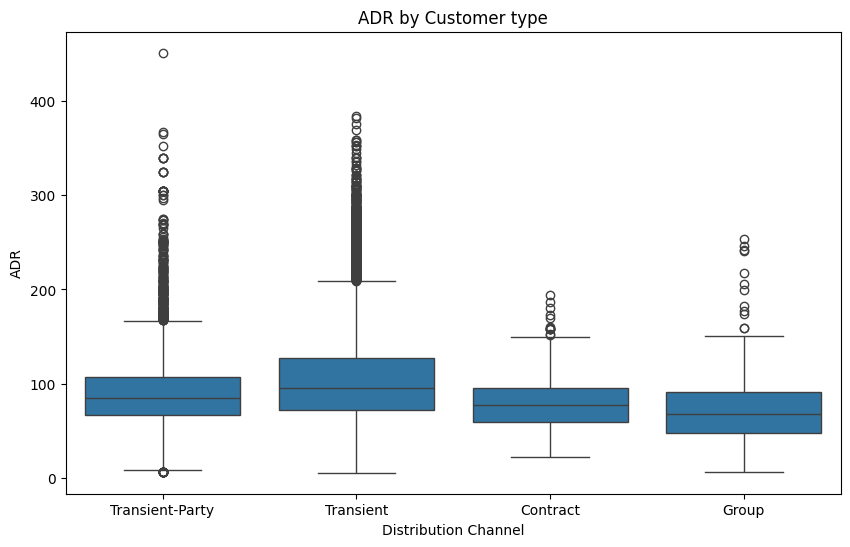

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='customer_type', y='adr', data=df)
plt.title('ADR by Customer type')
plt.xlabel('Distribution Channel')
plt.ylabel('ADR')
plt.show()

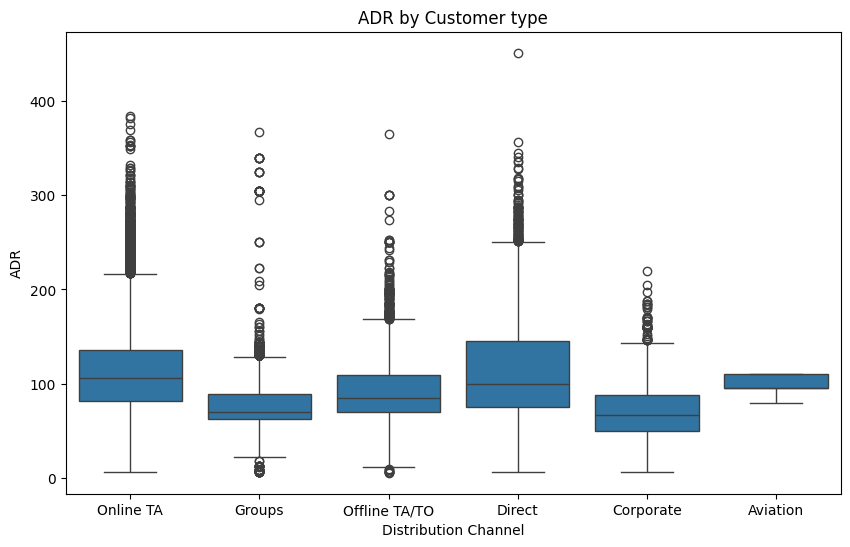

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='market_segment', y='adr', data=df)
plt.title('ADR by Customer type')
plt.xlabel('Distribution Channel')
plt.ylabel('ADR')
plt.show()

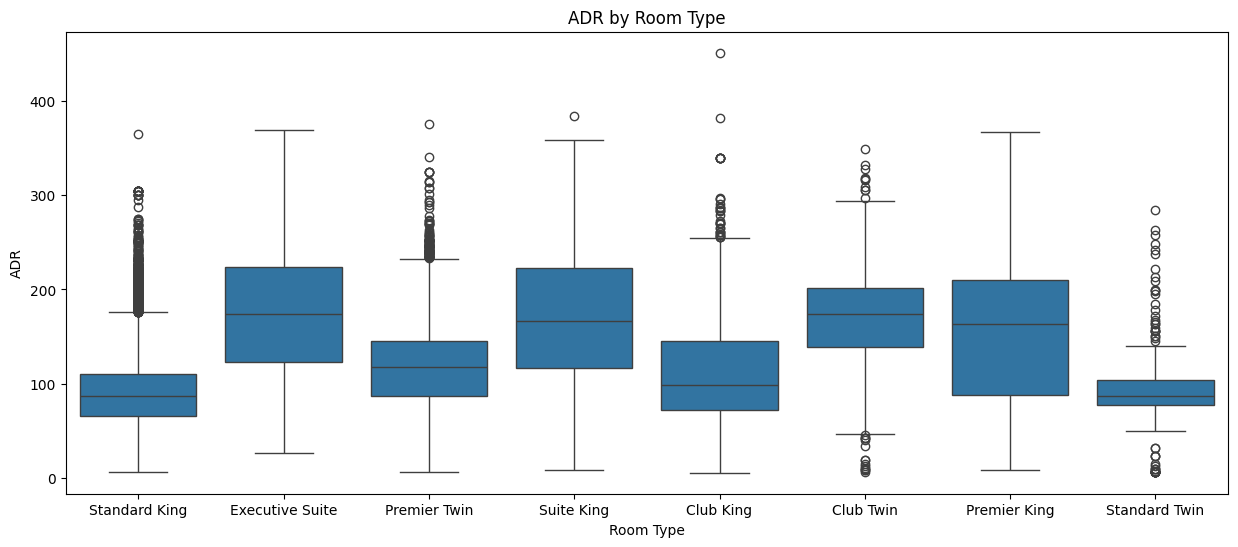

In [ ]:
# boxplot for ADR by Room type Channel
plt.figure(figsize=(15, 6))
sns.boxplot(x='room_class', y='adr', data=df)
plt.title('ADR by Room Type')
plt.xlabel('Room Type')
plt.ylabel('ADR')
plt.show()

<Axes: xlabel='reserved_room_type'>

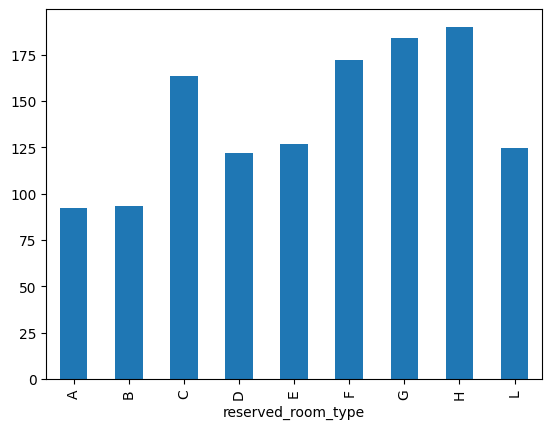

In [ ]:
# ADR by room type

X = df.groupby('reserved_room_type')['adr'].mean()


X.plot(kind='bar')